# Difference in Differences (DiD)


This scenario simulates a pre-post panel study of 600 workers to analyze COVID‑19 affecting the number of days employees work from home. 

* **Outcome variable:** The main outcome is **WFH days per week**, bounded between **0 and 5**.

* **Treatment:**
    -  **WFH feasibility:** Jobs have varying levels of **work‑from‑home feasibility**, highest in knowledge‑based roles and lowest in hands‑on occupations, with additional individual‑level variation.
    
* **Covariates:**:
    -   **Commute:** Each worker faces a **pre‑pandemic commute of varying length**, which influences post‑pandemic remote work behavior.
    -   **Individuals:** Each worker has fixed demographic characteristics, including **age** and **gender**.
    *   **Industries:** Workers are employed in one of three sectors—**knowledge**, **client‑facing**, or **hands‑on**—which differ systematically in their ability to support remote work.


* **To synthesize data, we need:**
    -   **Time structure:** The data include a **pre period** and a **post period**, where the post period represents the COVID‑19 shock to work arrangements.
    -   **Treatment heterogeneity:** In the post period, workers in more WFH‑feasible jobs experience **larger increases in remote work**, and **longer commutes further amplify** WFH adoption.
    -   **Unobserved heterogeneity:** **Individual fixed effects** capture persistent, unobserved preferences for working from home.

In [210]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
np.random.seed(7)

# Data generation process
N = 1000
ids = np.arange(N)
age = np.random.randint(22, 61, size=N)
gender = np.random.choice(["Male", "Female"], size=N, p=[0.5, 0.5])
industries = np.random.choice(
    ["Knowledge", "Client_facing", "Hands_on"],
    size=N, p=[0.45, 0.35, 0.20])

industry_feas = {"Knowledge": 0.75, "Client_facing": 0.35, "Hands_on": 0.10}
wfh_feasible = np.clip(
    np.array([industry_feas[i] for i in industries]) 
    + np.random.normal(0, 0.10, N), 0, 1)

commute_minutes = np.clip(
    np.random.lognormal(mean=np.log(30), sigma=0.6, size=N), 5, 120)

alpha = np.random.normal(0.5, 0.5, N)

rows = []
for post in [0, 1]:
    did_effect = 2.2 * post * wfh_feasible
    commute_effect = (post * 0.01) * commute_minutes
    age_effect = (age - 40) * 0.01
    gender_effect = np.where(gender == "Female", 0.05, 0.0)

    latent = (
        alpha + did_effect + commute_effect + age_effect 
        + gender_effect + np.random.normal(0, 0.5, N)
    )
    wfh_days = np.clip(latent, 0, 5)

    rows.append(pd.DataFrame({
        "id": ids,
        "post": post,
        "wfh_feasible": wfh_feasible,
        "wfh_days": wfh_days,
        "industry": industries,
        "commute_minutes": commute_minutes,
        "age": age,
        "gender": gender
    }))

df = pd.concat(rows, ignore_index=True)
print(df.shape)
df.head()

(2000, 8)


,id,post,wfh_feasible,wfh_days,industry,commute_minutes,age,gender
0,0,0,0.767103,0.000000,Knowledge,16.695450,26,Female
1,1,0,0.680485,0.212063,Knowledge,61.347978,47,Male
2,2,0,0.210852,0.000000,Hands_on,28.696251,25,Female
3,3,0,0.482801,0.407473,Client_facing,46.826358,41,Male
4,4,0,0.604703,0.212723,Client_facing,49.247203,45,Female


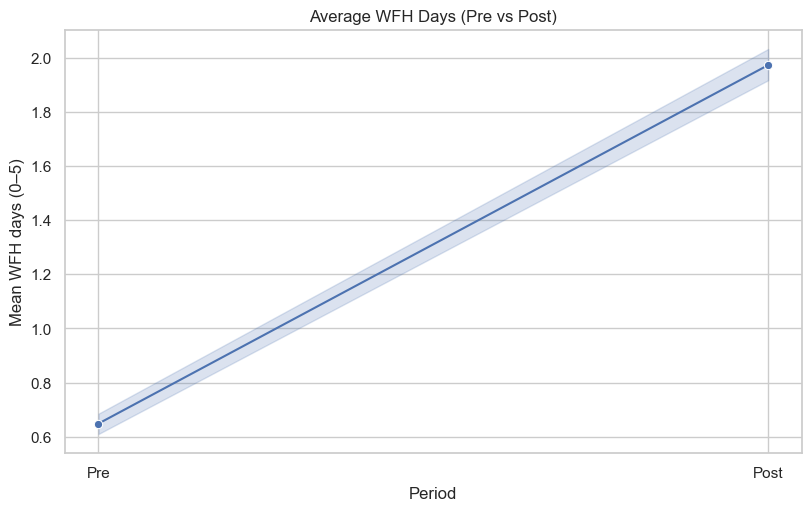

In [212]:
plot_df = df
plot_df['period'] = np.where(plot_df['post'] == 0, 'Pre','Post')
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.lineplot(
    data=plot_df,
    x='period',
    y='wfh_days',
    marker='o',
    ax=ax)
ax.set_title('Average WFH Days (Pre vs Post)')
ax.set_xlabel('Period')
ax.set_ylabel('Mean WFH days (0–5)')
plt.show()

In [213]:
# Dummies
df["gender_Male"] = (df["gender"] == "Male").astype(int)
industry_dummies = pd.get_dummies(df["industry"], prefix="industry").astype(int)
df = pd.concat([df, industry_dummies[["industry_Hands_on", "industry_Knowledge"]]], axis=1)
# Interaction (post:wfh_feasible)
df["post:feasible"] = df["post"].astype(float) * df["wfh_feasible"].astype(float)
df

,id,post,wfh_feasible,wfh_days,industry,commute_minutes,age,gender,period,gender_Male,industry_Hands_on,industry_Knowledge,post:feasible
0,0,0,0.767103,0.000000,Knowledge,16.695450,26,Female,Pre,0,0,1,0.000000
1,1,0,0.680485,0.212063,Knowledge,61.347978,47,Male,Pre,1,0,1,0.000000
2,2,0,0.210852,0.000000,Hands_on,28.696251,25,Female,Pre,0,1,0,0.000000
3,3,0,0.482801,0.407473,Client_facing,46.826358,41,Male,Pre,1,0,0,0.000000
4,4,0,0.604703,0.212723,Client_facing,49.247203,45,Female,Pre,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,995,1,0.000000,0.348140,Hands_on,29.452032,36,Male,Post,1,1,0,0.000000
1996,996,1,0.503471,2.216950,Client_facing,38.905732,23,Female,Post,0,0,0,0.503471
1997,997,1,0.143009,0.849192,Hands_on,41.545974,52,Female,Post,0,1,0,0.143009
1998,998,1,0.110806,0.161442,Client_facing,6.202983,39,Female,Post,0,0,0,0.110806


## Manual

#### Let’s start with the **canonical DiD regression**

- This has **one treated vs. one control** group.
- $
Y_{it}=\alpha+\beta_1\;\text{post}_t+\beta_2\;\text{treat}_i+\beta_3(\text{post}_t\times \text{treat}_i)+\varepsilon_{it}
$
- Here is the code:
```
import statsmodels.formula.api as smf
model = smf.ols('outcome ~ post + treatment + post:treatment', data=df).fit()
print(model.summary())
```

#### Add **controls** (same canonical DiD, but conditional)

- Often we add observables (commute time, age, gender) to improve precision:
- Columns (`dwfh`, `wfh_feasible`, `post`, `commute_minutes`, `age`, `gender_Male`)

# OLS

In [214]:
import statsmodels.formula.api as smf

formula_ols = (
    'wfh_days ~ post + wfh_feasible + post:wfh_feasible'
    ' + commute_minutes + age'
    ' + gender_Male + industry_Hands_on + industry_Knowledge')
ols_model = smf.ols(formula=formula_ols, data=df).fit(cov_type='HC3')
print(ols_model.summary())

# The coefficient of interest (ATE on the interaction)
beta_interaction = ols_model.params["post:wfh_feasible"]
se_interaction = ols_model.bse["post:wfh_feasible"]
print({"ols_interaction_beta": beta_interaction, "ols_interaction_se": se_interaction})

                            OLS Regression Results                            
Dep. Variable:               wfh_days   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     361.8
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:11:32   Log-Likelihood:                -1955.6
No. Observations:                2000   AIC:                             3929.
Df Residuals:                    1991   BIC:                             3980.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2118      0

# DoWhy

In [218]:
from dowhy import CausalModel
# Build the model
model = CausalModel(
    data=df,
    treatment="post:feasible",
    outcome="wfh_days",
    common_causes=[
        "post", "wfh_feasible", "commute_minutes", "age",
        "gender_Male", "industry_Hands_on", "industry_Knowledge"] )

identified_estimand = model.identify_effect()
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
────────────────(E[wfh_days|post,industry_Hands_on,gender_Male,industry_Knowle ↪
d[post:feasible]                                                               ↪

↪                                       
↪ dge,wfh_feasible,age,commute_minutes])
↪                                       
Estimand assumption 1, Unconfoundedness: If U→{post:feasible} and U→wfh_days then P(wfh_days|post:feasible,post,industry_Hands_on,gender_Male,industry_Knowledge,wfh_feasible,age,commute_minutes,U) = P(wfh_days|post:feasible,post,industry_Hands_on,gender_Male,industry_Knowledge,wfh_feasible,age,commute_minutes)

## Realized estimand
b: wfh_days~post:feasible+post+industry_Hands_on+gender_Male+industry_Knowledge+wfh_feasible+age+commute_minutes
Target units: ate

## Estimat

In [219]:
# --- Placebo Treatment Refuter ---
ref_placebo = model.refute_estimate(
    identified_estimand, estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",       # shuffle treatment values
    num_simulations=100,
    random_state=7
)
print("\n[Refuter: PLACEBO]")
print(ref_placebo)

# --- Data Subset Refuter ---
ref_subset = model.refute_estimate(
    identified_estimand, estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.80,         # use 80% of data each time
    num_simulations=100,
    random_state=7
)
print("\n[Refuter: SUBSET]")
print(ref_subset)

# --- Bootstrap Refuter ---
ref_bootstrap = model.refute_estimate(
    identified_estimand, estimate,
    method_name="bootstrap_refuter",
    num_simulations=200,
    resample_size=0.80,
    random_state=7
)
print("\n[Refuter: BOOTSTRAP]")
print(ref_bootstrap)

# --- Random Common Cause Refuter ---
ref_random_cc = model.refute_estimate(
    identified_estimand, estimate,
    method_name="random_common_cause",
    num_simulations=100,
    random_state=7
)
print("\n[Refuter: RANDOM COMMON CAUSE]")
print(ref_random_cc)


[Refuter: PLACEBO]
Refute: Use a Placebo Treatment
Estimated effect:1.9920578529673185
New effect:0.0017015831530447078
p value:0.88


[Refuter: SUBSET]
Refute: Use a subset of data
Estimated effect:1.9920578529673185
New effect:2.092955980595984
p value:0.0


[Refuter: BOOTSTRAP]
Refute: Bootstrap Sample Dataset
Estimated effect:1.9920578529673185
New effect:1.8486763272379267
p value:0.0


[Refuter: RANDOM COMMON CAUSE]
Refute: Add a random common cause
Estimated effect:1.9920578529673185
New effect:1.992163258636475
p value:0.8999999999999999



## Refuter-by-refuter interpretation

### 1) **Placebo Treatment Refuter**

*   **New effect (placebo):** **0.0017** (≈ 0)
*   **p-value:** **0.88**
*   **Interpretation:** We deliberately **break** the causal link by permuting the treatment. The estimate collapses to \~0, which is exactly what we **want**—it suggests your original effect is **not** an artifact of spurious correlation.
*   **Bottom line:** **Pass.** The design is behaving as expected under placebo.
*   **Magnitude check:** $$-1.9904$$ absolute change from the original (≈ **−100%**).

> Note on p-values in DoWhy refuters: For placebo and random common cause, DoWhy reports a p-value from an internal test; the **magnitude** of the new estimate is usually the more intuitive signal. Here, the fact that the placebo effect is \~0 is the key robustness indicator.

### 2) **Data Subset Refuter**

*   **New effect (subset, 80% samples):** **2.0930**
*   **p-value:** **0.0**
*   **Interpretation:** Re-estimating the effect on random 80% subsets gives a result very close to the original (difference ≈ **+0.101** or **+5.1%**). The **p-value = 0.0** indicates the mean subset estimate is statistically different from the original given the large sample/precision, but **practically** the change is modest.
*   **Bottom line:** **Robust in magnitude.** Small sensitivity consistent with sampling variability.

### 3) **Bootstrap Refuter**

*   **New effect (bootstrap, 80% resample):** **1.8479**
*   **p-value:** **0.0**
*   **Interpretation:** The bootstrap average is a bit lower than the original (difference ≈ **−0.144** or **−7.2%**). With high precision, the test flags the difference. Still, the **effect remains large and positive**, close to the original.
*   **Bottom line:** **Robust in magnitude**, with modest sensitivity under resampling—consistent with your DGP’s noise and the outcome clipping.

***

### 4) **Random Common Cause Refuter**

*   **New effect (with random noise covariate):** **1.99216**
*   **p-value:** **0.90**
*   **Interpretation:** Adding a synthetic, irrelevant covariate barely moves the estimate (difference ≈ **+0.0001** or **+0.005%**). This indicates the estimate is **not** overly sensitive to additional (uninformative) controls.
*   **Bottom line:** **Pass.** Very stable to extraneous covariates.


## Overall takeaway

*   All four refuters give results **consistent** with a real causal signal:
    *   **Placebo**: Effect collapses to \~0 when treatment is broken ⇒ **good**.
    *   **Subset** & **Bootstrap**: The effect remains **large and positive**; small-to-moderate changes (≈ +5% and −7%) reflect sampling variability, precision, and the clipping of `wfh_days` to $$[0,5]$$.
    *   **Random Common Cause**: Effect is essentially **unchanged**, suggesting robustness to irrelevant covariates.

Given your data-generating parameter of **2.2** on the interaction, the observed estimates (≈ **1.99–2.09**) are in the right ballpark; the slight downward bias is expected from the **noise** and **clipping** in the outcome.
